In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
import joblib
import pickle

In [2]:
data=pd.read_csv('Datasets\coin_Bitcoin.csv')
data

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\91981\AppData\Local\Temp\ipykernel_7996\2018799515.py:1: SyntaxWarning: invalid escape sequence '\c'
  data=pd.read_csv('Datasets\coin_Bitcoin.csv')


,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Bitcoin,BTC,2013-04-29 23:59:59,147.488007,134.000000,134.444000,144.539993,0.000000e+00,1.603769e+09
1,2,Bitcoin,BTC,2013-04-30 23:59:59,146.929993,134.050003,144.000000,139.000000,0.000000e+00,1.542813e+09
2,3,Bitcoin,BTC,2013-05-01 23:59:59,139.889999,107.720001,139.000000,116.989998,0.000000e+00,1.298955e+09
3,4,Bitcoin,BTC,2013-05-02 23:59:59,125.599998,92.281898,116.379997,105.209999,0.000000e+00,1.168517e+09
4,5,Bitcoin,BTC,2013-05-03 23:59:59,108.127998,79.099998,106.250000,97.750000,0.000000e+00,1.085995e+09
...,...,...,...,...,...,...,...,...,...,...
2986,2987,Bitcoin,BTC,2021-07-02 23:59:59,33939.588699,32770.680780,33549.600177,33897.048590,3.872897e+10,6.354508e+11
2987,2988,Bitcoin,BTC,2021-07-03 23:59:59,34909.259899,33402.696536,33854.421362,34668.548402,2.438396e+10,6.499397e+11
2988,2989,Bitcoin,BTC,2021-07-04 23:59:59,35937.567147,34396.477458,34665.564866,35287.779766,2.492431e+10,6.615748e+11
2989,2990,Bitcoin,BTC,2021-07-05 23:59:59,35284.344430,33213.661034,35284.344430,33746.002456,2.672155e+10,6.326962e+11


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2991 entries, 0 to 2990
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SNo        2991 non-null   int64  
 1   Name       2991 non-null   object 
 2   Symbol     2991 non-null   object 
 3   Date       2991 non-null   object 
 4   High       2991 non-null   float64
 5   Low        2991 non-null   float64
 6   Open       2991 non-null   float64
 7   Close      2991 non-null   float64
 8   Volume     2991 non-null   float64
 9   Marketcap  2991 non-null   float64
dtypes: float64(6), int64(1), object(3)
memory usage: 233.8+ KB


In [4]:
data.isnull().sum()

SNo          0
Name         0
Symbol       0
Date         0
High         0
Low          0
Open         0
Close        0
Volume       0
Marketcap    0
dtype: int64

In [5]:
data['Name'].unique()

array(['Bitcoin'], dtype=object)

In [6]:
data['Symbol'].unique()

array(['BTC'], dtype=object)

In [7]:
data['Date'].unique()

array(['2013-04-29 23:59:59', '2013-04-30 23:59:59',
       '2013-05-01 23:59:59', ..., '2021-07-04 23:59:59',
       '2021-07-05 23:59:59', '2021-07-06 23:59:59'], dtype=object)

In [8]:
X=data[['High', 'Low', 'Open', 'Volume', 'Marketcap']]
y=data['Close']

In [9]:
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state=42)

In [10]:
scaler=RobustScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [28]:
model_linear=LinearRegression()
model_svr=SVR(kernel='linear')
model_tree=DecisionTreeRegressor()

In [12]:
model_linear.fit(X_train,y_train)

LinearRegression()

In [14]:
predictions_linear=model_linear.predict(X_test)

In [16]:
acc_linear=r2_score(predictions_linear, y_test)
acc_linear

0.9997488659144373

In [17]:
train=model_linear.predict(X_train)
acc_linear_t=r2_score(train, y_train)
acc_linear_t

0.9997480455506438

In [29]:
model_svr.fit(X_train, y_train)


SVR(kernel='linear')

In [30]:
predictions_svr=model_svr.predict(X_test)
acc_svr=r2_score(predictions_svr, y_test)
acc_svr

0.9712820423564827

In [31]:
train2=model_svr.predict(X_train)
acc_svr_t=r2_score(train2, y_train)
acc_svr_t

0.9697877066666534

In [33]:
model_tree.fit(X_train,y_train)

DecisionTreeRegressor()

In [34]:
predictions_tree=model_tree.predict(X_test)
acc_tree=r2_score(predictions_tree, y_test)
acc_tree

0.9997573965437444

In [35]:
train3=model_tree.predict(X_train)
acc_tree_t=r2_score(train3, y_train)
acc_tree_t

1.0

Text(0, 0.5, 'Predicted Close Prce')

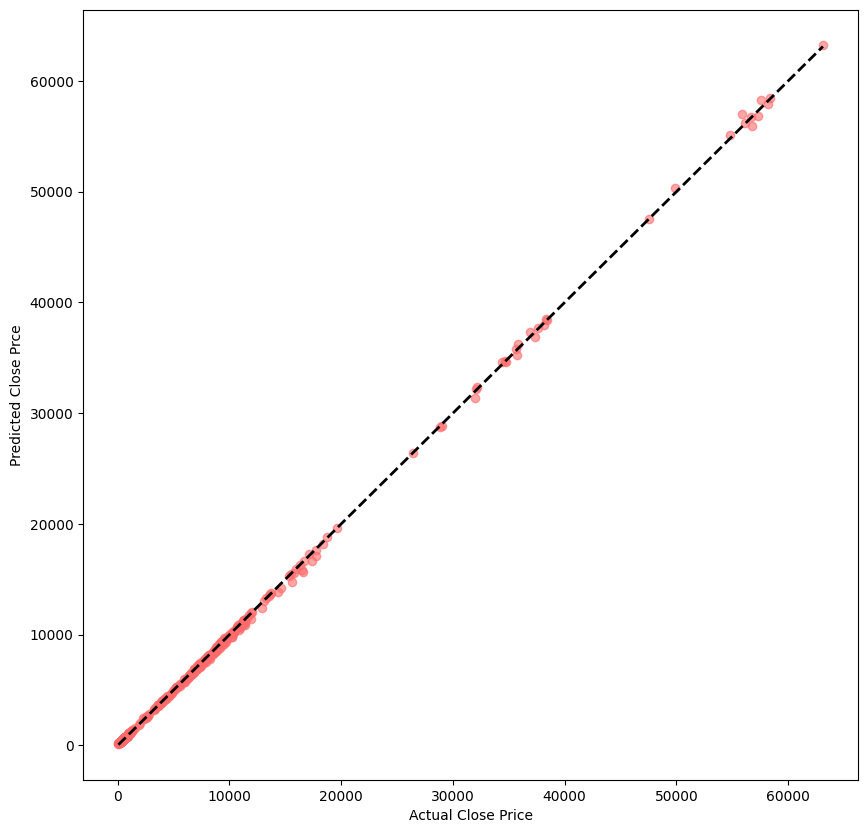

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.scatter(y_test, predictions_linear, alpha=0.6, color='#FF6B6B')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Prce')

Text(0, 0.5, 'Predicted Close Prce')

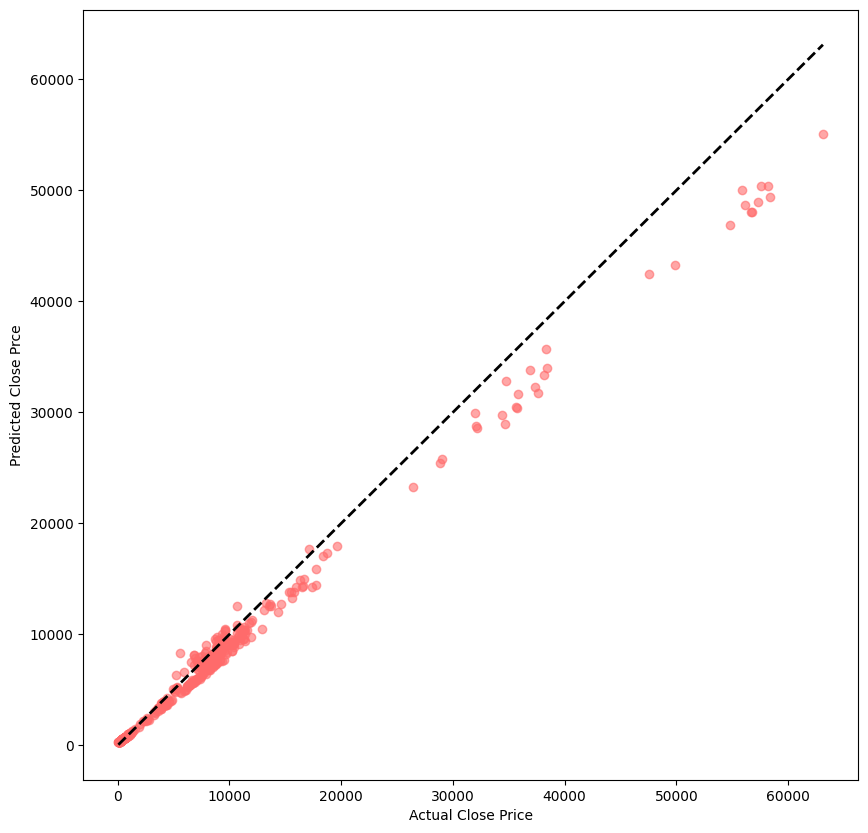

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.scatter(y_test, predictions_svr, alpha=0.6, color='#FF6B6B')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Prce')

Text(0, 0.5, 'Predicted Close Prce')

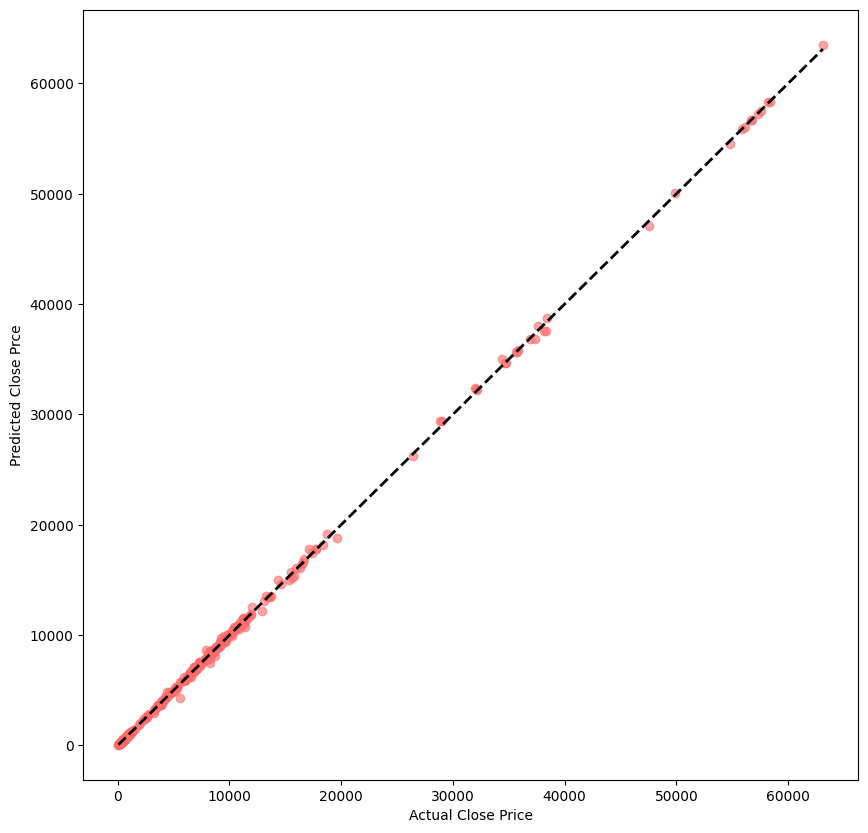

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.scatter(y_test, predictions_tree, alpha=0.6, color='#FF6B6B')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Prce')